# Introduction 

Employee attrition has been a severe and ongoing issue for organizations for many years. When an employee — upon whom a lot of time and energy has been invested — chooses to leave for "greener pastures," it results in additional cost and effort to recruit and train a replacement. In the best tradition of Kaggle, we turn to predictive modeling to address this issue, in this instance using a synthetically generated IBM dataset to predict employee attrition.

This notebook is organized as follows:

1. **Exploratory Data Analysis (EDA)**: We begin with the exploration of the dataset, plotting feature distributions, examining correlations between variables, and visualizing using Seaborn and Plotly.

2. **Feature Engineering and Categorical Encoding**: In this section, we engineer new features and encode categorical variables into dummy/encoded variables for data modeling.

3. **Machine Learning Model Implementation**: We build and compare various tree-based machine learning models, and interpret feature importances from these models.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Import statements required for Plotly 
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, log_loss, classification_report)
from imblearn.over_sampling import SMOTE
import xgboost

# Import and suppress warnings
import warnings
warnings.filterwarnings('ignore')

# 1. Exploratory Data Analysis



In [2]:
#Loading the data 
data = pd.read_csv('../input/WA_Fn-UseC_-HR-Employee-Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


Target column - **"Attrition"** column. 



**Data quality checks**



In [3]:
# Looking for NaN or null values
display(data.isnull().any())

Age                         False
Attrition                   False
BusinessTravel              False
DailyRate                   False
Department                  False
DistanceFromHome            False
Education                   False
EducationField              False
EmployeeCount               False
EmployeeNumber              False
EnvironmentSatisfaction     False
Gender                      False
HourlyRate                  False
JobInvolvement              False
JobLevel                    False
JobRole                     False
JobSatisfaction             False
MaritalStatus               False
MonthlyIncome               False
MonthlyRate                 False
NumCompaniesWorked          False
Over18                      False
OverTime                    False
PercentSalaryHike           False
PerformanceRating           False
RelationshipSatisfaction    False
StandardHours               False
StockOptionLevel            False
TotalWorkingYears           False
TrainingTimesL

We see there are no null values in any column 

### Distribution of the dataset

Generally one of the first few steps in exploring the data would be to have a rough idea of how the features are distributed. So we do a distribution plot for numerical features 

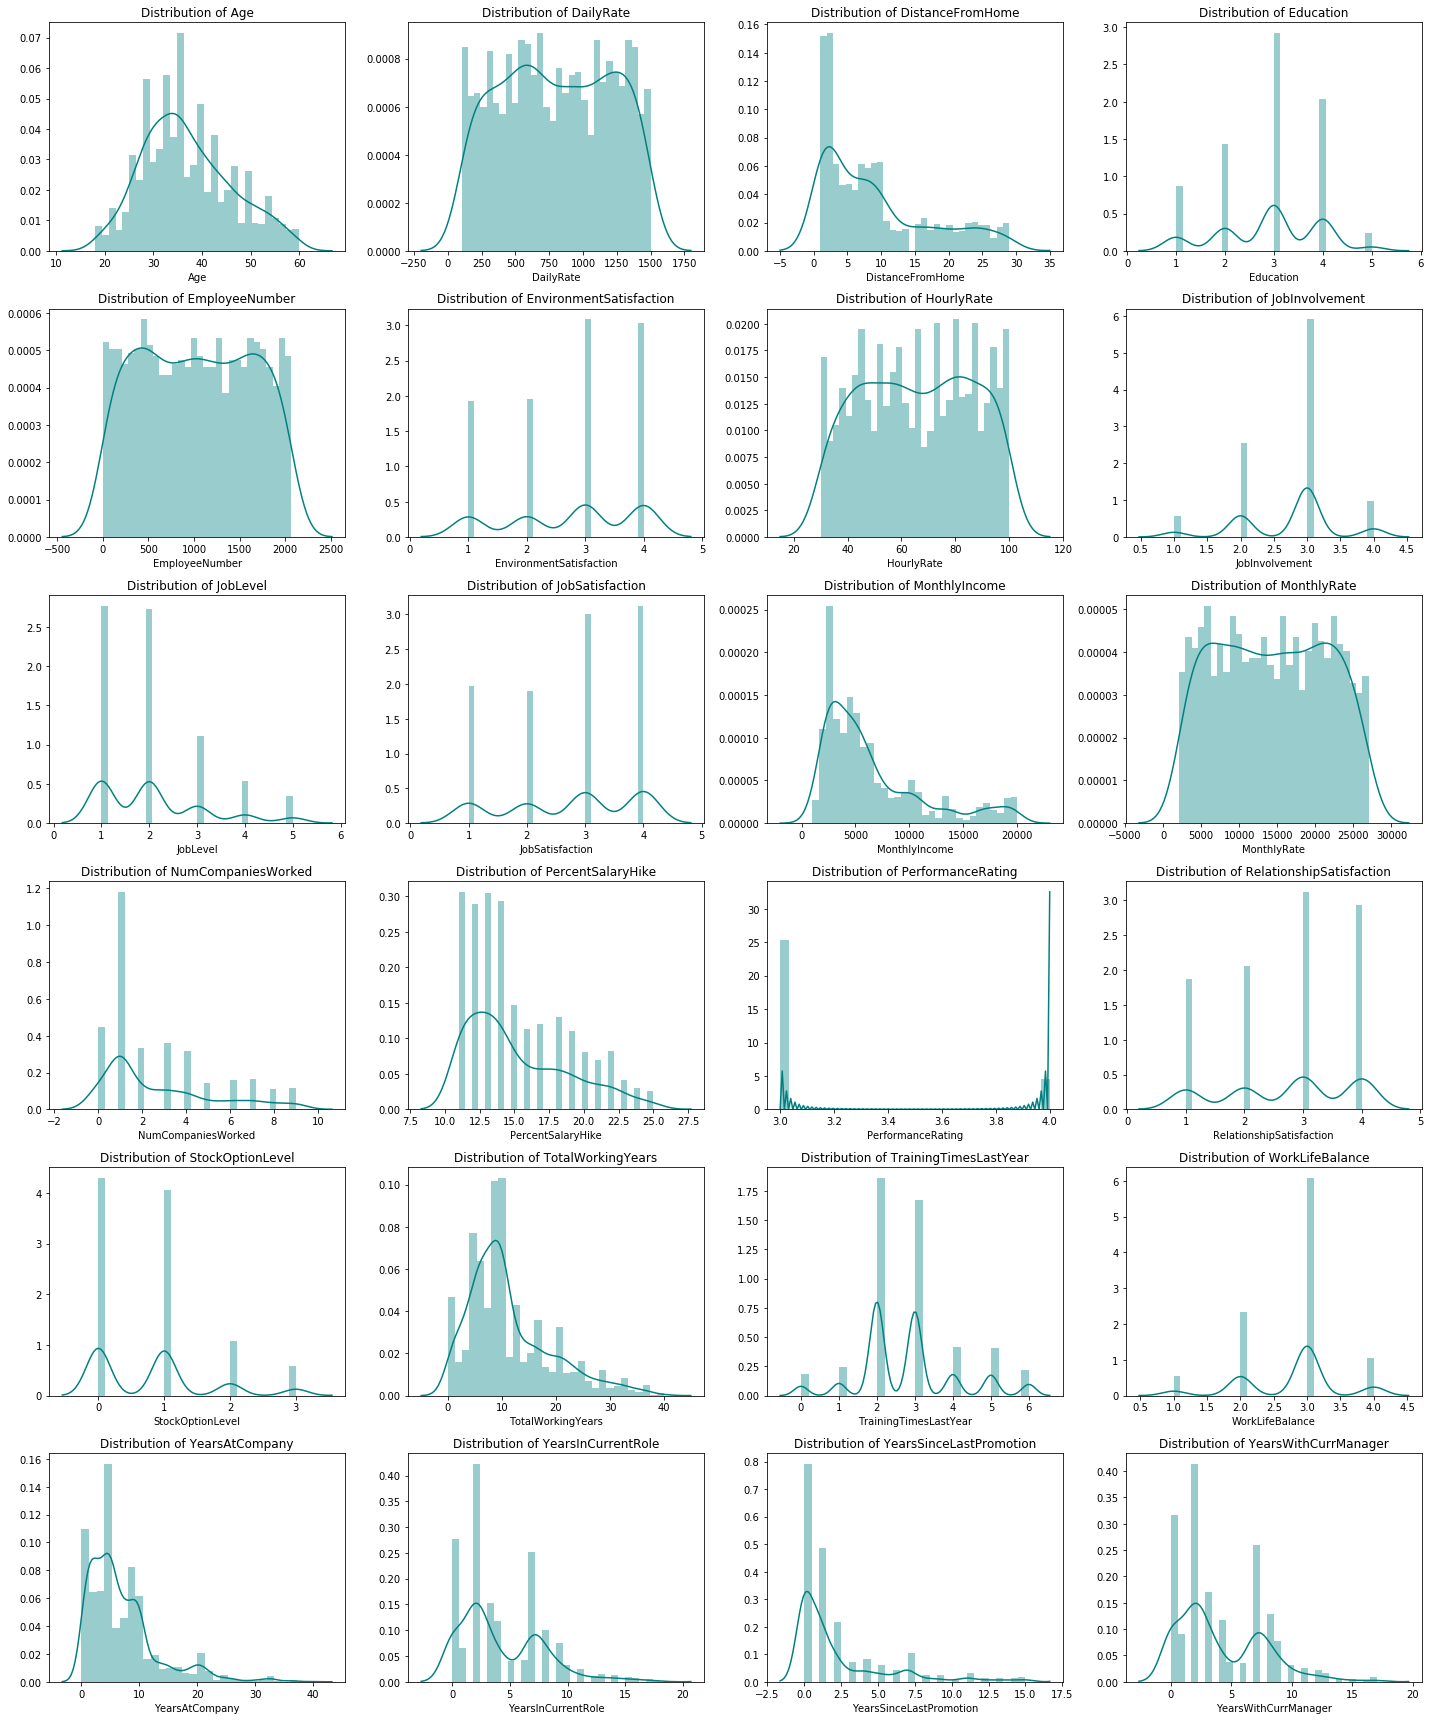

In [4]:
numerical = [u'Age', u'DailyRate', u'DistanceFromHome', 
             u'Education', u'EmployeeNumber', u'EnvironmentSatisfaction',
             u'HourlyRate', u'JobInvolvement', u'JobLevel', u'JobSatisfaction',
             u'MonthlyIncome', u'MonthlyRate', u'NumCompaniesWorked',
             u'PercentSalaryHike', u'PerformanceRating', u'RelationshipSatisfaction',
             u'StockOptionLevel', u'TotalWorkingYears',
             u'TrainingTimesLastYear', u'WorkLifeBalance', u'YearsAtCompany',
             u'YearsInCurrentRole', u'YearsSinceLastPromotion',u'YearsWithCurrManager']# your numeric columns
# List of numerical columns (as you've already defined)
ncols = 4  # number of columns per row
nrows = -(-len(numerical) // ncols)  # ceiling division to determine number of rows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()  # Flatten in case it's a 2D array

for i, name in enumerate(numerical):
    sns.distplot(data[name], ax=axes[i], bins=30, color='teal')
    axes[i].set_title(f'Distribution of {name}')

# Remove unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
print(data[numerical].dtypes)

Age                         int64
DailyRate                   int64
DistanceFromHome            int64
Education                   int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobSatisfaction             int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
dtype: object


In [6]:
# Define a dictionary for the target mapping
target_map = {'Yes':1, 'No':0}
# Use the pandas apply method to numerically encode our attrition target variable
data["Attrition_numerical"] = data["Attrition"].apply(lambda x: target_map[x])

### Correlation of Features

By plotting a correlation matrix, we have a very nice overview of how the features are related to one another. For a Pandas dataframe, we can conveniently use the call **.corr** which by default provides the Pearson Correlation values of the columns pairwise in that dataframe.



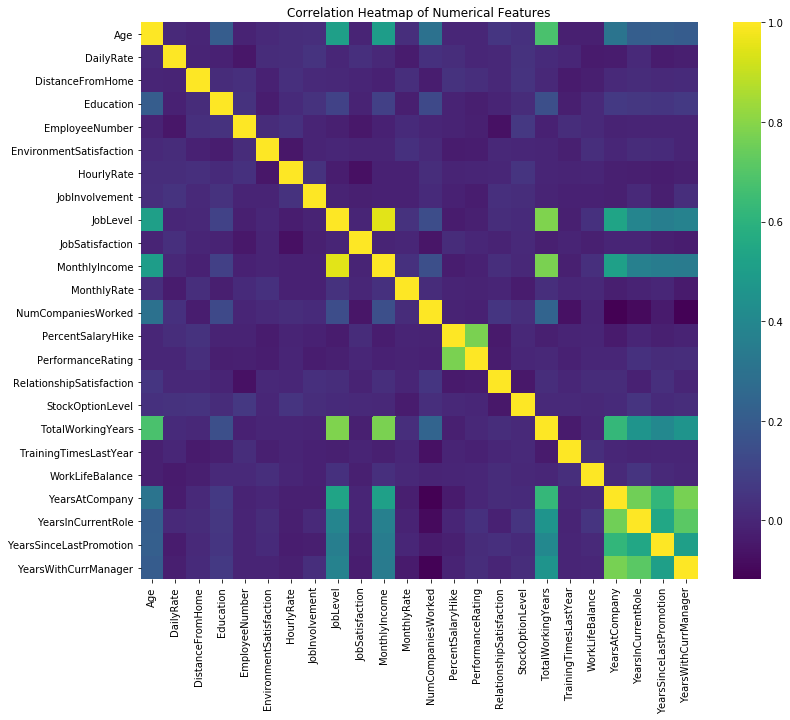

In [7]:
corr = data[numerical].corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(corr, cmap='viridis', square=True, cbar=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [8]:
# Compute the correlation matrix
corr_matrix = data[numerical].corr().abs()

# Select the upper triangle of the correlation matrix (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Drop those features from your data
data = data.drop(columns=to_drop)

# Show dropped columns
print("Dropped columns:", to_drop)

Dropped columns: ['MonthlyIncome']


Dropping the columns which are highly correlated, i.e, correlation score more than 0.8

**Takeaway from the plots**

From the correlation plots, we can see that quite a lot of our columns seem to be poorly correlated with one another. Generally when making a predictive model, it would be preferable to train a model with features that are not too correlated with one another so that we do not need to deal with redundant features. 

### Pairplot Visualisations

Now let us create some Seaborn pairplots and set it against the target variable which is our Attrition column to get a feel for how the various features are distributed vis-a-vis employee attrition

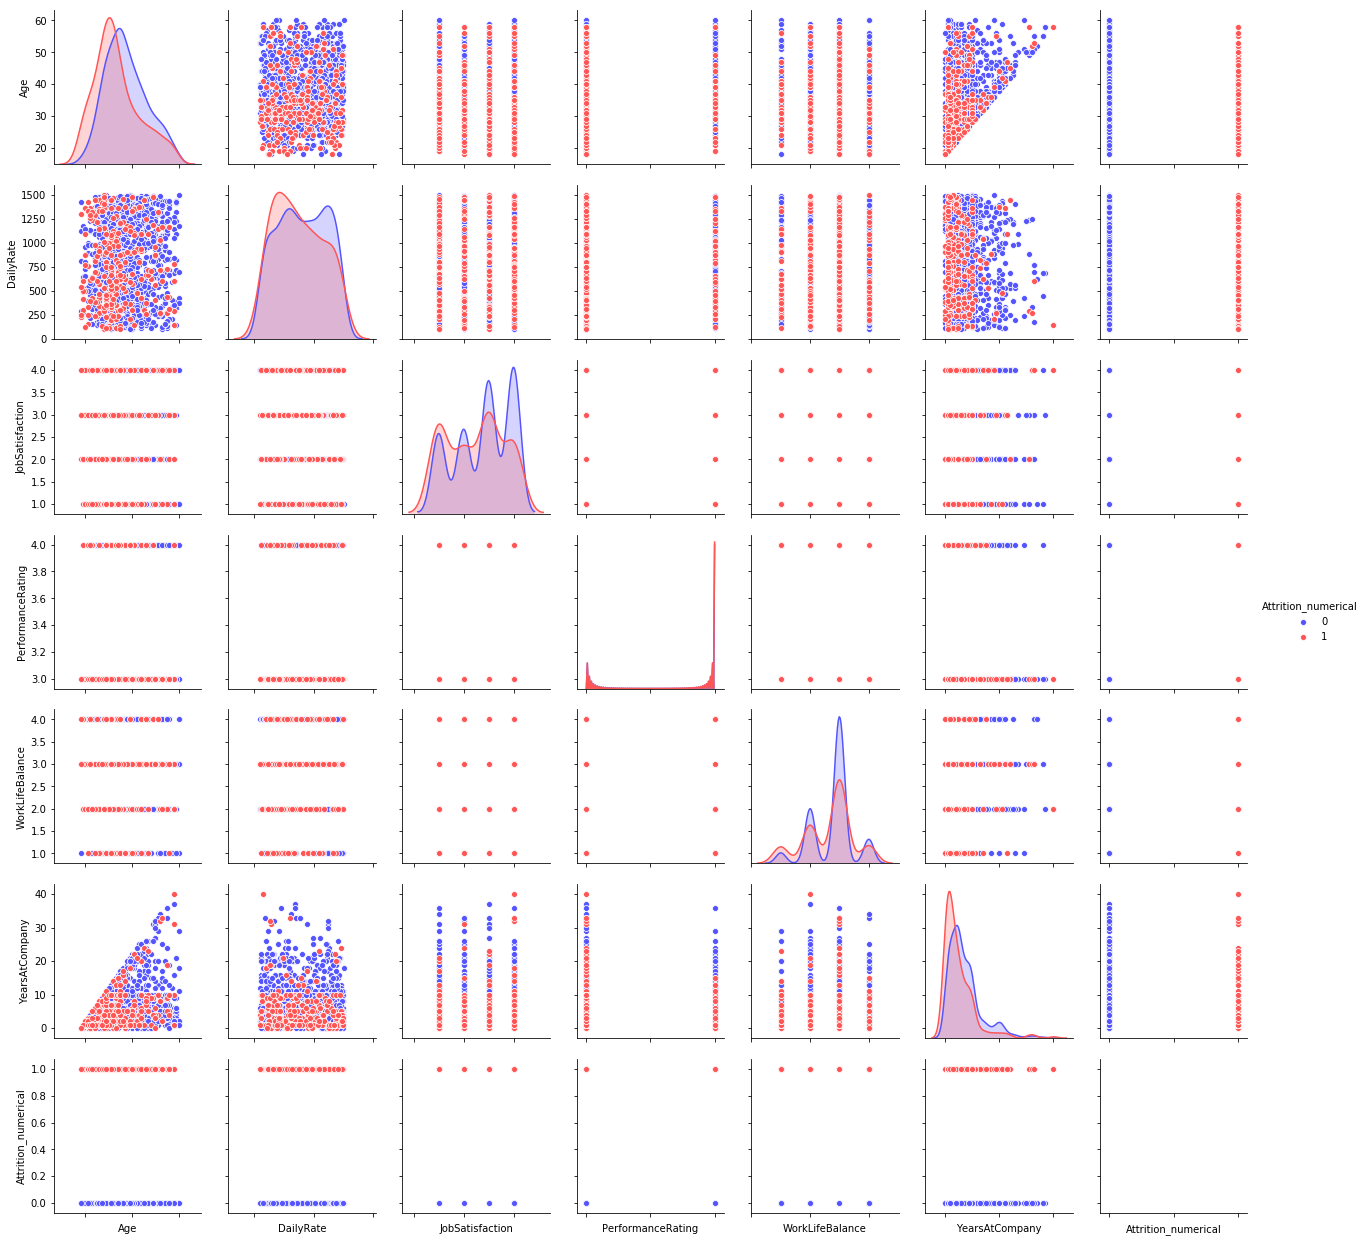

In [9]:
# Refining our list of numerical variables
numerical = [u'Age', u'DailyRate',  u'JobSatisfaction',
        u'PerformanceRating',
        u'WorkLifeBalance', u'YearsAtCompany', u'Attrition_numerical']

g = sns.pairplot(data[numerical], hue='Attrition_numerical', palette='seismic', diag_kind = 'kde',diag_kws=dict(shade=True))
g.set(xticklabels=[])

# 2. Feature Engineering & Categorical Encoding

Having carried out a brief exploration into the dataset, let us now proceed onto the task of Feature engineering and numerically encoding the categorical values in our dataset. Feature engineering in a nutshell involves creating new features and relationships from the current features that we have. Feature engineering has been quite 

To start off, we shall segregate numerical columns from categorical columns via the use of the dtype method as follows:

In [10]:
# Drop the Attrition_numerical column from attrition dataset first - Don't want to include that
data = data.drop(['Attrition_numerical'], axis=1)

# Empty list to store columns with categorical data
categorical = []
for col, value in data.iteritems():
    if value.dtype == 'object':
        categorical.append(col)

# Store the numerical columns in a list numerical
numerical = data.columns.difference(categorical)

Having identified which of our features contain categorical data, we can set about numerically encoding the data. To do this, I shall use the **get_dummies** method from Pandas which creates encoded dummy variables from the categorical variables.

In [11]:
# Store the categorical data in a dataframe called attrition_cat
data_cat = data[categorical]
data_cat = data_cat.drop(['Attrition'], axis=1) # Dropping the target column

Applying the **get_dummies** method, we see that we have encoded our categorical values conveniently by just applying one line of Python code. 

In [12]:
data_cat = pd.get_dummies(data_cat)
data_cat.head(3)

,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,1
1,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0
2,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1


**Creating new features from Numerical data**

In [13]:
# Store the numerical features to a dataframe attrition_num
data_num = data[numerical]

Having encoded our categorical columns as well as engineering and created some new features from the numerical data, we can now proceed to merging both dataframes into a final set with which we will train and test our models on. 

In [14]:
# Concat the two dataframes together columnwise
data_final = pd.concat([data_num, data_cat], axis=1)

**Target variable**

One final step that that we have to remember is to generate our target variable. The target in this case is given by the column **Attrition** which contains categorical variables therefore requires numerical encoding. We numerically encode it by creating a dictionary with the mapping given as 1 : Yes and 0 : No

In [15]:
# Define a dictionary for the target mapping
target_map = {'Yes':1, 'No':0}
# Use the pandas apply method to numerically encode our attrition target variable
target = data["Attrition"].apply(lambda x: target_map[x])
target.head(3)

0    1
1    0
2    1
Name: Attrition, dtype: int64

However just by a quick inspection of the counts of the number of 'Yes' and 'No' in the target variable tells us that there is quite a large skew in target as shown

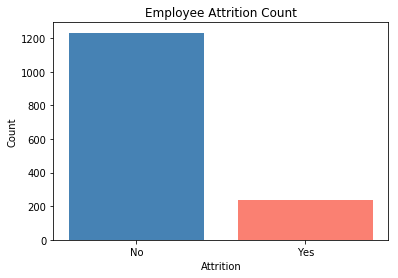

In [16]:
attrition_counts = data["Attrition"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(attrition_counts.index, attrition_counts.values, color=['steelblue', 'salmon'])
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

Therefore we have to keep in mind that there is quite a big imbalance in our target variable. Many statistical techniques have been put forth to treat imbalances in data (oversampling or undersampling). In this notebook, I will use an oversampling technique known as SMOTE to treat this imbalance.

# 3. Implementing Machine Learning Models

Having performed some exploratory data analysis and simple feature engineering as well as having ensured that all categorical values are encoded, we are now ready to proceed onto building our models.

As alluded to in the introduction of this notebook, we will aim to evaluate and contrast the performances of a handful of different learning models. 

**Splitting Data into Train and Test sets**

But before we even start training a model, we will have to partition our dataset into a training set and a test set (unlike Kaggle competitions where the train and test data are already segregated for you). To split our data we will utilise sklearn's 

In [17]:
# Import the train_test_split method
from sklearn.cross_validation import train_test_split
from sklearn.cross_validation import StratifiedShuffleSplit

# Split data into train and test sets as well as for validation and testing
train, test, target_train, target_val = train_test_split(data_final, 
                                                         target, 
                                                         train_size= 0.80,
                                                         random_state=0);
#train, test, target_train, target_val = StratifiedShuffleSplit(attrition_final, target, random_state=0);

**SMOTE to oversample due to the skewness in target**

Since we have already noted the severe imbalance in the values within the target variable, let us implement the SMOTE method in the dealing with this skewed value via the imblearn Python package.

In [18]:
oversampler=SMOTE(random_state=0)
smote_train, smote_target = oversampler.fit_sample(train,target_train)

----
## A. Random Forest Classifier 
The decision tree as a standalone model is often considered a "weak learner" as its predictive performance is relatively poor. However a Random Forest gathers a group (or ensemble) of decision trees and uses their combined predictive capabilities to obtain relatively strong predictive performance - "strong learner". 

This principle of using a collection of "weak learners" to come together to create a "strong learner" underpins the basis of ensemble methods which one regularly comes across in Machine learning. 

**Initialising Random Forest parameters**

We will utilise the Scikit-learn library to construct a Random Forest model. To do so, we have to first define our set of parameters that we will feed into our Random Forest classifier as follows

In [19]:
seed = 0   # We set our random seed to zero for reproducibility
# Random Forest parameters
rf_params = {
    'n_jobs': -1,
    'n_estimators': 1000,
    'max_features': 0.3,
    'max_depth': 4,
    'min_samples_leaf': 2,
    'max_features' : 'sqrt',
    'random_state' : seed,
    'verbose': 0
}

In [20]:
rf = RandomForestClassifier(**rf_params)

The next step after prepping our Random Forest model would be to start building a forest of trees using our training set and fitting it to our attrition target variable. We do so by simply using the **fit** call as follows

In [21]:
rf.fit(smote_train, smote_target)
print("Fitting of Random Forest finished")

Fitting of Random Forest finished


Having fitted our forest of trees with our parameters to the training set against our target variable, we now have a learning model **rf** which we can make predictions out of. To use our Random Forest in predicting against our test data, we can use sklearn's **.predict** method as follows

In [22]:
rf_predictions = rf.predict(test)
print("Predictions finished")

Predictions finished


Scoring the model

In [23]:
print("Accuracy score: {}".format(accuracy_score(target_val, rf_predictions)))
print("="*80)
print(classification_report(target_val, rf_predictions))

Accuracy score: 0.8537414965986394
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       245
           1       0.57      0.49      0.53        49

   micro avg       0.85      0.85      0.85       294
   macro avg       0.74      0.71      0.72       294
weighted avg       0.85      0.85      0.85       294



**Accuracy of the model**

As observed, our Random Forest returns an accuracy of approx 85% for its predictions and on first glance this might seem to be a pretty good performing model. However when we think about how skewed our target variable where the distribution of yes and no's are 17% and 83%, therefore our model is only predicting slightly better than random guessing. 

It would be more informative to balance out the precision and recall scores as show in the classification report outputs. Where it falls down to the business considerations over whether one should prioritise for a metric over the other - i.e. your Precision vs Recall.

### Feature Ranking via the Random Forest 

The Random Forest classifier in Sklearn also contains a very convenient  attribute **feature_importances_** which tells us which features within our dataset has been given most importance through the Random Forest algorithm. Shown below is an Interactive Plotly diagram of the various feature importances.

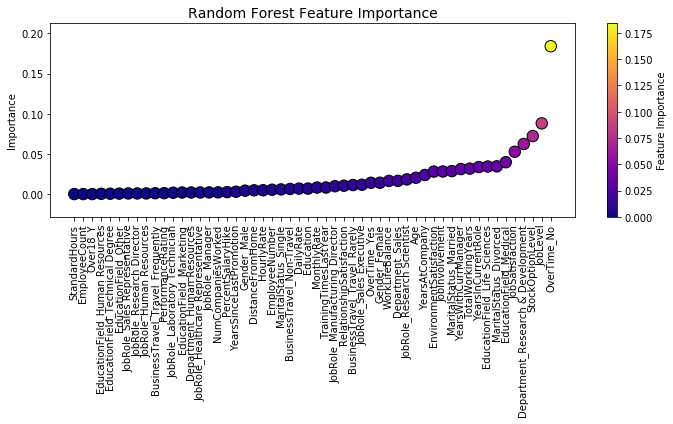

In [24]:


# Assuming rf is your trained RandomForest model
importances = rf.feature_importances_
features = data_final.columns.values

# Sort by importance
indices = np.argsort(importances)

# Set up figure
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=features[indices],
    y=importances[indices],
    c=importances[indices],
    cmap='plasma',
    s=130,  # marker size
    edgecolor='k'
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Feature Importance")

# Formatting
plt.title("Random Forest Feature Importance", fontsize=14)
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.grid(False)
plt.tight_layout()

plt.show()


----

## B. Gradient Boosted Classifier

Gradient Boosting is also an ensemble technique much like the Random Forest where a combination of weak Tree learners are brought together to form a relatively stronger learner. The technique involves defining some sort of function (loss function) that you want minimised and an method/algorithm to minimise this. Therefore as the name suggests, the algorithm used to minimise the loss function is that of a gradient descent method which adds decision trees which "point" in the direction that reduces our loss function (downward gradient).


**Initialising Gradient Boosting Parameters** 

In general there are a handful of key parameter when setting up tree-based or gradient boosted models. These are always going to be the number of estimators, the maximum depth with which you want your model to be trained to, and the minimum samples per leaf

In [25]:
# Gradient Boosting Parameters
gb_params ={
    'n_estimators': 1500,
    'max_features': 0.9,
    'learning_rate' : 0.25,
    'max_depth': 4,
    'min_samples_leaf': 2,
    'subsample': 1,
    'max_features' : 'sqrt',
    'random_state' : seed,
    'verbose': 0
}

Having defined our parameters, we can now apply the usual fit and predict methods on our train and test sets respectively 

In [26]:
gb = GradientBoostingClassifier(**gb_params)
# Fit the model to our SMOTEd train and target
gb.fit(smote_train, smote_target)
# Get our predictions
gb_predictions = gb.predict(test)
print("Predictions have finished")

Predictions have finished


In [27]:
print(accuracy_score(target_val, gb_predictions))
print(classification_report(target_val, gb_predictions))

0.8469387755102041
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       245
           1       0.58      0.29      0.38        49

   micro avg       0.85      0.85      0.85       294
   macro avg       0.73      0.62      0.65       294
weighted avg       0.82      0.85      0.82       294



### Feature Ranking via the Gradient Boosting Model

Much like the Random Forest, we can invoke the feature_importances_ attribute of the gradient boosting model and dump it in an interactive Plotly chart

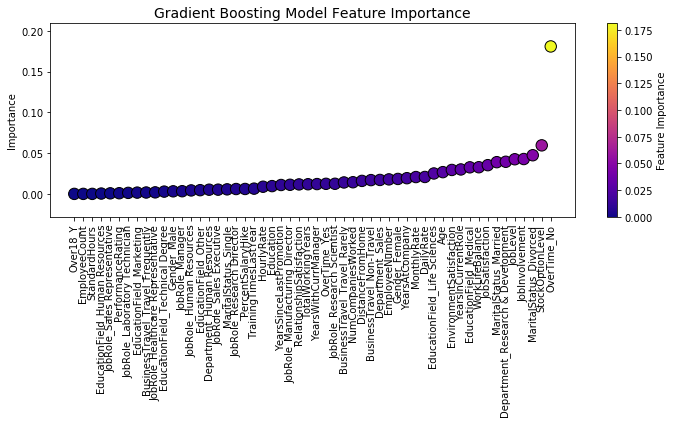

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances and feature names
importances = gb.feature_importances_
features = data_final.columns.values

# Sort by importance
indices = np.argsort(importances)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=features[indices],
    y=importances[indices],
    c=importances[indices],
    cmap='plasma',
    s=130,
    edgecolor='k'
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Feature Importance")

# Format the plot
plt.title("Gradient Boosting Model Feature Importance", fontsize=14)
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.grid(False)
plt.tight_layout()

plt.show()


### CONCLUSION

We have constructed a very simple pipeline of predicting employee attrition, from some basic Exploratory Data Analysis to feature engineering as well as training two learning models in the form of a Random Forest as well as a Gradient Boosting classifier.

Lastly, while both Random Forest as well as Gradient Boosting possess comparable overall accuracy (~85%), Random Forest clearly surpasses in identifying workers who are more likely to quit (class 1), with improved recall as well as F1-score.
In spite of the fact that SMOTE had been applied to address class imbalance, Gradient Boosting model continued to underperform on recall for class 1. This means that oversampling alone wasn't sufficient, and also highlights Gradient Boosting's vulnerability to synthetic data and hyperparameters. Alternatively, Random Forest handled imbalance handling better, owing largely to its noise resistance and averaging inherent within it. With respect to boosting methods, further tuning or more advanced resampling may be needed to produce similar performance.